# **Import Everything**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)
print('Everything is imported boss')

Everything is imported boss


# **Data Exploration**

## **Load the Data**

In [3]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [4]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 4040 Rows and 7 columns with 39 Duplicates


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4040 entries, 0 to 4039
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  3959 non-null   str    
 1   sepal_width_cm   3960 non-null   float64
 2   petal_length_cm  3959 non-null   float64
 3   petal_width_cm   3958 non-null   float64
 4   leaf_area_cm2    3959 non-null   float64
 5   stem_height_cm   3960 non-null   float64
 6   species          4040 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 236.8 KB


In [8]:
df.sample(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,leaf_area_cm2,stem_height_cm,species
874,6.08,2.60,4.03,1.32,13.31,52.87,1
140,6.73,2.82,6.11,0.43,9.73,14.82,1
1937,5.76,3.01,5.73,1.09,10.66,25.25,1
3064,7.23,3.26,2.34,NaN,19.78,15.06,1
2290,4.61,3.52,2.59,1.59,6.39,47.46,0
2231,6.69,3.67,5.40,1.50,4.06,74.24,1
3396,7.61,2.06,6.40,1.55,11.68,16.67,1
1327,4.89,2.80,3.02,0.16,14.65,51.39,0
2029,4.64,4.08,6.59,1.62,13.72,18.89,1
2163,7.61,3.49,4.23,2.34,NaN,60.74,1


In [9]:
df.describe()

,sepal_width_cm,petal_length_cm,petal_width_cm,leaf_area_cm2,stem_height_cm,species
count,3960.000000,3959.000000,3958.000000,3959.000000,3960.000000,4040.000000
mean,3.257980,4.021740,1.325579,11.040200,44.648051,0.494802
std,0.730221,1.746217,0.696073,9.361412,20.505099,0.500035
min,2.000000,-3.000000,-1.000000,2.000000,-10.000000,0.000000
25%,2.660000,2.510000,0.730000,6.420000,26.900000,0.000000
50%,3.260000,4.030000,1.340000,10.830000,44.540000,0.000000
75%,3.850000,5.550000,1.930000,15.330000,62.665000,1.000000
max,15.000000,7.000000,2.500000,500.000000,79.970000,1.000000


In [12]:
df.isna().sum()

sepal_length_cm    81
sepal_width_cm     80
petal_length_cm    81
petal_width_cm     82
leaf_area_cm2      81
stem_height_cm     80
species             0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [13]:
df_copy = df.copy()
print('Copy Created baby')

Copy Created baby


## **DataType**

In [15]:
df_copy['sepal_length_cm'] = df_copy['sepal_length_cm'].replace('_err','',regex=True).astype('float')

## **Impossible values**

In [18]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [20]:
Columns = df_copy.columns.tolist()
Columns.remove('species')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [22]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 40
After: 0


## **NaN Values**

In [23]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('species')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
sepal_length_cm    81
sepal_width_cm     81
petal_length_cm    81
petal_width_cm     81
leaf_area_cm2      81
stem_height_cm     81
species             0
dtype: int64
NaN values in the Dataset After Cleaning is: 
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
leaf_area_cm2      0
stem_height_cm     0
species            0
dtype: int64


# **Data Preperattion**

In [24]:
features = df_copy.columns.tolist()
features.remove('species')
X = df_copy[features]
y = df_copy['species']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (4000, 6)
y Shape: (4000,)


In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (3200, 6)
X_test Shape:  (800, 6)
y_train Shape: (3200,)
y_test Shape:  (800,)


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Suggested starting K: {int(math.sqrt(len(X_train)))}")

Suggested starting K: 56


# **Model**

## **Optimal K**

In [28]:
train_scores = []
test_scores  = []
k_range      = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(test_scores)]
print(f"Optimal K: {best_k}")

Optimal K: 29


## **Train**

In [37]:
model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',   # distance metric
    weights='uniform'     # all neighbors vote equally
)

model.fit(X_train_scaled, y_train)
print(f"Model trained with K={best_k} ✅")

Model trained with K=29 ✅


## **Evaluation & Pridict**

In [38]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       404
         1.0       0.89      0.88      0.88       396

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800

Accuracy: 0.8862


## **OverFitiing Check**

In [39]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8997
Testing Accuracy:  0.8862
Gap:               0.0134


## **Charts**

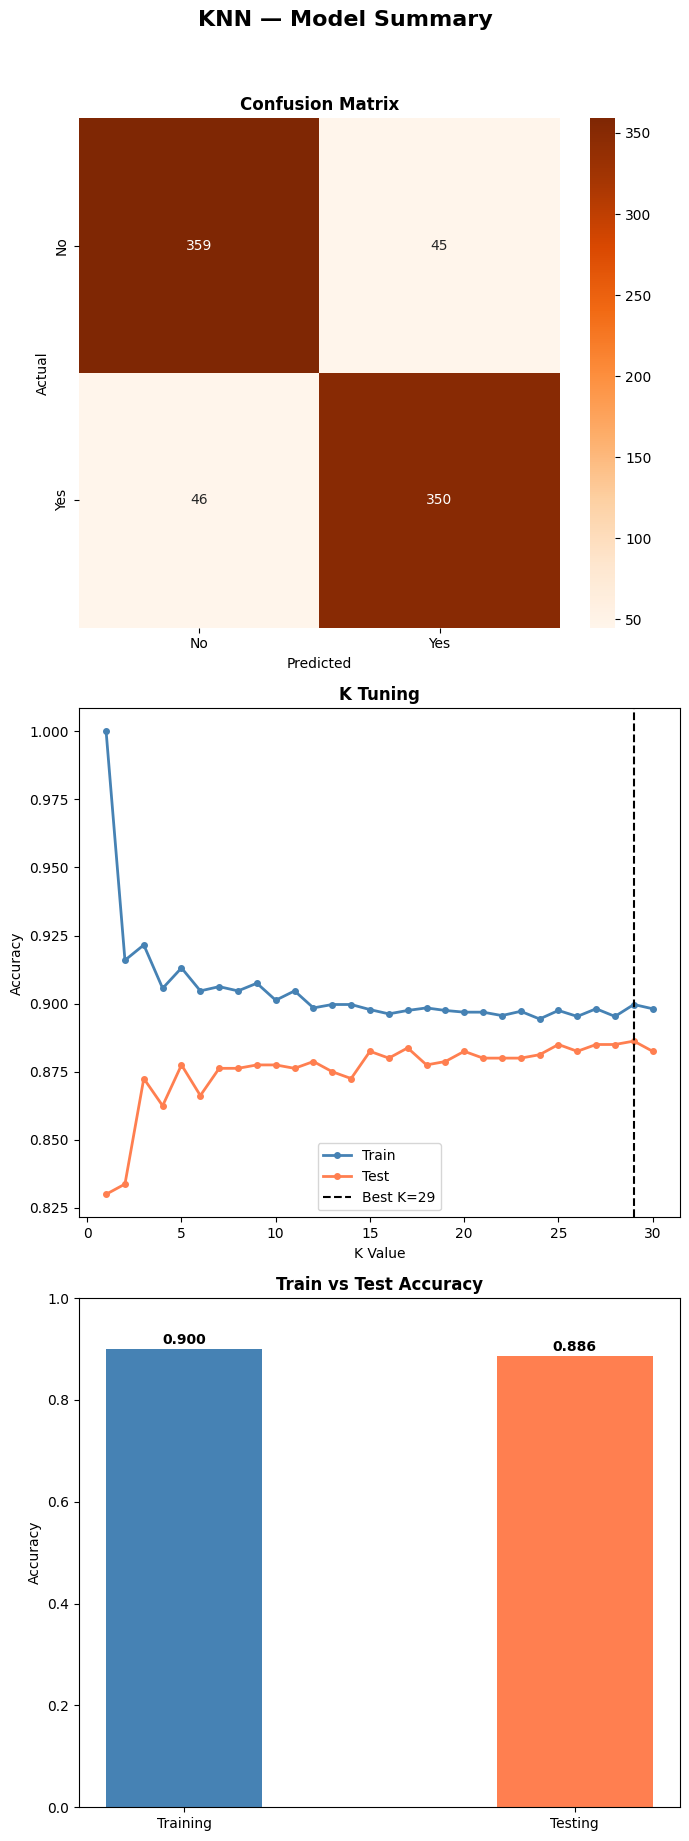

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — K Tuning
axes[1].plot(k_range, train_scores, marker='o', markersize=4,
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(k_range, test_scores,  marker='o', markersize=4,
             label='Test',  color='coral',     linewidth=2)
axes[1].axvline(best_k, linestyle='--', color='black',
                label=f'Best K={best_k}')
axes[1].set_title('K Tuning', fontweight='bold')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('KNN — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()